# NYKA 

## Problem statement

1. Analysis on Beauty products.
2. Analysis on Healthcare products.
3. Analysis on Baby products.

In [2]:
!pip install requests
!pip install beautifulsoup4
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install lxml

In [24]:
# Step 2: Import Libraries

import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [17]:
pip install selenium

Note: you may need to restart the kernel to use updated packages.


In [18]:
import selenium
print(selenium.__version__)

4.46.0


In [113]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from bs4 import BeautifulSoup
import time

# Open Chrome
driver = webdriver.Chrome()

# Open Nykaa Makeup page
url = "https://www.nykaa.com/makeup/c/12"
driver.get(url)

# Wait for page to load
time.sleep(8)

# Print page title
print(driver.title)

# Create BeautifulSoup object
soup = BeautifulSoup(driver.page_source, "html.parser")

print("BeautifulSoup created successfully")

Buy Makeup Products Online For Everyday Effortless Look
BeautifulSoup created successfully


## SCRAPING THE DATA

## Beauty Products

In [154]:
product_name = []
product_link = []
original_price = []
selling_price = []
discount = []
rating = []

for product in products:

    # Product Name
    name = product.find("h2", class_="css-xrzmfa")
    product_name.append(name.text.strip() if name else None)

    # Product Link
    href = product.get("href")
    if href:
        product_link.append("https://www.nykaa.com" + href)
    else:
        product_link.append(None)

    # Original Price
    op = product.find("span", class_="css-17x46n5")
    original_price.append(op.text.strip() if op else None)

    # Selling Price
    sp = product.find("span", class_="css-111z9ua")
    selling_price.append(sp.text.strip() if sp else None)

    # Discount
    dis = product.find("span", class_="css-cjd9an")
    discount.append(dis.text.strip() if dis else None)

    # Rating
    rate = product.find("div", attrs={"aria-label": True})
    rating.append(rate["aria-label"] if rate else None)

In [28]:
import pandas as pd

df = pd.read_csv("Nykaa_Beauty_Products.csv")

df

,Product Name,Original Price,Selling Price,Discount,Rating,Product Link
0,Flicka Silk Touch 3-In-1 Moisturizer Primer An...,₹899,₹791,12% Off,4 out of 5 star rating,https://www.nykaa.com/flicka-silk-touch-milk-c...
1,Charlotte Tilbury Airbrush Flawless Setting Spray,₹3700,₹2960,20% Off,5 out of 5 star rating,https://www.nykaa.com/charlotte-tilbury-airbru...
2,Kay Beauty Full Coverage Cloud Cushion Foundat...,₹1599,₹1279,20% Off,4 out of 5 star rating,https://www.nykaa.com/kay-beauty-hydra-cloud-c...
3,e.l.f. Cosmetics Power Grip Primer,₹1300,₹910,30% Off,5 out of 5 star rating,https://www.nykaa.com/e-l-f-cosmetics-power-gr...
4,Nykaa Matte to Last No Transfer Long Lasting L...,₹599,₹419,30% Off,4 out of 5 star rating,https://www.nykaa.com/nykaa-cosmetics-matte-to...
...,...,...,...,...,...,...
95,Nykaa Cosmetics Eyes On Me! 10-in-1 Eyeshadow ...,₹699,₹350,50% Off,4 out of 5 star rating,https://www.nykaa.com/nykaa-eyes-on-me-10-in-1...
96,Lakme Xtraordin-Airy Mattereal Mousse Foundati...,₹1099,₹604,45% Off,4 out of 5 star rating,https://www.nykaa.com/lakme-absolute-mattreal-...
97,Swiss Beauty Real Make-Up Base Highlighting Pr...,₹429,₹322,25% Off,4 out of 5 star rating,https://www.nykaa.com/swiss-beauty-real-make-u...
98,Renee Cosmetics Bollywood Filter Blurring Matt...,₹440,₹395,10% Off,4 out of 5 star rating,https://www.nykaa.com/renee-cosmetics-bollywoo...


##  Healthcare Products

In [71]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import pandas as pd
import time


driver = webdriver.Chrome()

driver.get("https://www.nykaa.com/health-wellness/c/671")

driver.maximize_window()

time.sleep(5)


# Scroll to load products
for i in range(5):
    driver.execute_script(
        "window.scrollTo(0, document.body.scrollHeight);"
    )
    time.sleep(3)


# Find product cards
products = driver.find_elements(
    By.XPATH,
    "//div[contains(@class,'productWrapper')]"
)


product_list = []


for product in products:

    text = product.text.split("\n")

    data = {
        "Product Name": "",
        "Original Price": "",
        "Selling Price": "",
        "Discount": "",
        "Reviews": ""
    }


    for line in text:

        if "₹" in line:
            if data["Original Price"] == "":
                data["Original Price"] = line
            else:
                data["Selling Price"] = line


        elif "%" in line and "Off" in line:
            data["Discount"] = line


        elif "(" in line and ")" in line:
            data["Reviews"] = line


    # Product name is usually after badges like AD/BESTSELLER
    for line in text:
        if (
            "₹" not in line
            and "%" not in line
            and "(" not in line
            and line not in ["AD", "BESTSELLER"]
            and len(line) > 5
        ):
            data["Product Name"] = line
            break


    product_list.append(data)



# Convert to dataframe
df = pd.DataFrame(product_list)





# Save CSV
df.to_csv(
    "nykaa_health_products.csv",
    index=False
)


driver.quit()

In [72]:
df.to_csv(
    "nykaa_health_products.csv",
    index=False
)

df

,Product Name,Original Price,Selling Price,Discount,Reviews
0,Chicnutrix Mighty Collagen Japanese Marine Col...,₹1800,Regular price ₹1800. Discounted price ₹999. 44...,44% Off,( 209 )
1,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",₹649,Regular price ₹649. Discounted price ₹549. 15%...,Extra 10% Off,( 11567 )
2,HealthKart Hk Vitals Skin Radiance Collagen Su...,₹975,Regular price ₹975. Discounted price ₹889. 9% ...,9% Off,( 9387 )
3,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",₹999,Regular price ₹999. Discounted price ₹849. 15%...,Extra 10% Off,( 11567 )
4,Forest Essentials Sandalwood & Saffron Ayurved...,Price ₹1295.,₹1295,,( 6 )
5,Max Care Virgin Coconut Oil Cold Pressed,₹325,Regular price ₹325. Discounted price ₹293. 10%...,10% Off,( 101580 )
6,Plum BodyLovin Vanilla Vibes Body Oil,₹299,Regular price ₹299. Discounted price ₹257. 14%...,14% Off,( 44447 )
7,Beautywise Skin Brilliance Glutathione Dual Ac...,₹2899,Regular price ₹2899. Discounted price ₹2174. 2...,25% Off,( 1526 )
8,Krishna's Diabic Care Juice Clinically Proven ...,Price ₹459.,₹459,,( 200 )
9,,Price ₹2054.,₹2054,,( 345 )


##  Baby Products

In [73]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import pandas as pd
import time
import re

# Launch Chrome
driver = webdriver.Chrome()

driver.maximize_window()

# Open Baby Care page
driver.get("https://www.nykaa.com/mom-baby/baby-care/c/14798")

time.sleep(5)

# Scroll to load more products
for i in range(5):
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(3)

# Find all product cards
products = driver.find_elements(
    By.XPATH,
    "//div[contains(@class,'productWrapper')]"
)

print("Number of Products:", len(products))

product_data = []

for product in products:

    lines = product.text.split("\n")

    data = {
        "Product Name": "",
        "Original Price": "",
        "Selling Price": "",
        "Discount": "",
        "Reviews": ""
    }

    # -----------------------------
    # Product Name
    # -----------------------------
    for line in lines:

        if line in ["AD", "BESTSELLER"]:
            continue

        if (
            "₹" not in line
            and "%" not in line
            and "(" not in line
            and "Regular price" not in line
            and "Enjoy Free Gift" not in line
            and "Extra" not in line
            and "Sizes" not in line
            and len(line) > 5
        ):
            data["Product Name"] = line
            break

    # -----------------------------
    # Prices
    # -----------------------------
    prices = []

    for line in lines:
        prices.extend(re.findall(r'₹\d+', line))

    if len(prices) >= 2:
        data["Original Price"] = prices[0]
        data["Selling Price"] = prices[1]

    elif len(prices) == 1:
        data["Original Price"] = prices[0]
        data["Selling Price"] = prices[0]

    # -----------------------------
    # Discount
    # -----------------------------
    for line in lines:
        if "%" in line:
            discount = re.search(r'(\d+)', line)

            if discount:
                data["Discount"] = discount.group(1)
                break

    # -----------------------------
    # Reviews
    # -----------------------------
    for line in lines:
        review = re.search(r'\((.*?)\)', line)

        if review:
            number = re.sub(r"\D", "", review.group(1))
            data["Reviews"] = number
            break

    product_data.append(data)

# -----------------------------
# Create DataFrame
# -----------------------------
df = pd.DataFrame(product_data)

# Save CSV
# -----------------------------
df.to_csv(
    "nykaa_baby_care_products.csv",
    index=False
)

print("\nCSV file saved successfully.")

driver.quit()

Number of Products: 20

CSV file saved successfully.


In [75]:
df.to_csv("baby_care.csv", index=False)
df

,Product Name,Original Price,Selling Price,Discount,Reviews
0,Aveeno Baby Daily Moisture Wash & Shampoo - Na...,₹863,₹690,20,4830
1,Max Care Virgin Coconut Oil Cold Pressed,₹325,₹293,10,101580
2,Orimii Bump Hydrating Body Butter for Reducing...,₹695,₹660,5,334
3,Aveeno Baby Daily Moisture Lotion | Oatmeal Fa...,₹1050,₹899,14,1716
4,Nat Habit Brahmi Matsyakshi Summer Dasabuti Ba...,₹435,₹309,29,177
5,Bare Anatomy Junior Gentle Cleansing Shampoo,₹978,₹860,12,4067
6,Aveeno Baby Daily Moisture Lotion | Oatmeal Fa...,₹1650,₹1403,15,234
7,Cetaphil Baby Wash & Shampoo with Organic Cale...,₹1499,₹1349,10,1473
8,Nat Habit Pure Almond Baby Oil,₹1248,₹861,31,279
9,Orimii Belly Treatment Elixir - Body Oil For S...,₹695,₹660,5,280


# Final Dataset

In [1]:
import pandas as pd

# Read the CSV files
beauty_df = pd.read_csv("Nykaa_Beauty_Products.csv")
healthcare_df = pd.read_csv("nykaa_health_products.csv")
babycare_df = pd.read_csv("nykaa_baby_care_products.csv")

# Add category labels
beauty_df["Category"] = "Beauty"
healthcare_df["Category"] = "Healthcare"
babycare_df["Category"] = "Baby Care"

# Combine all three dataframes
combined_df = pd.concat(
    [beauty_df, healthcare_df, babycare_df],
    ignore_index=True
)

# Save the combined dataframe
combined_df.to_csv("Nykaa_All_Products.csv", index=False)

print("Combined DataFrame created successfully!")
print(combined_df.shape)
#combined_df.head()

Combined DataFrame created successfully!
(140, 8)


In [2]:
import pandas as pd

df = pd.read_csv("Nykaa_All_Products.csv")

In [3]:
df.head(20)

,Product Name,Original Price,Selling Price,Discount,Rating,Product Link,Category,Reviews
0,Flicka Silk Touch 3-In-1 Moisturizer Primer An...,₹899,₹791,12% Off,4 out of 5 star rating,https://www.nykaa.com/flicka-silk-touch-milk-c...,Beauty,NaN
1,Charlotte Tilbury Airbrush Flawless Setting Spray,₹3700,₹2960,20% Off,5 out of 5 star rating,https://www.nykaa.com/charlotte-tilbury-airbru...,Beauty,NaN
2,Kay Beauty Full Coverage Cloud Cushion Foundat...,₹1599,₹1279,20% Off,4 out of 5 star rating,https://www.nykaa.com/kay-beauty-hydra-cloud-c...,Beauty,NaN
3,e.l.f. Cosmetics Power Grip Primer,₹1300,₹910,30% Off,5 out of 5 star rating,https://www.nykaa.com/e-l-f-cosmetics-power-gr...,Beauty,NaN
4,Nykaa Matte to Last No Transfer Long Lasting L...,₹599,₹419,30% Off,4 out of 5 star rating,https://www.nykaa.com/nykaa-cosmetics-matte-to...,Beauty,NaN
5,Rare Beauty Soft Pinch Matte Liquid Blush,NaN,₹3200,NaN,5 out of 5 star rating,https://www.nykaa.com/rare-beauty-soft-pinch-m...,Beauty,NaN
6,"Lakme 9 To 5 Powerplay Priming Matte Lipstick,...",₹650,₹358,45% Off,4 out of 5 star rating,https://www.nykaa.com/lakme-9-to-5-primer-matt...,Beauty,NaN
7,Maybelline New York Lash Sensational Sky High ...,₹829,₹705,15% Off,4 out of 5 star rating,https://www.nykaa.com/maybelline-new-york-lash...,Beauty,NaN
8,Nykaa Cosmetics So Creme! Creamy Matte Lipstick,₹329,₹165,50% Off,4 out of 5 star rating,https://www.nykaa.com/nykaa-so-creme-creamy-ma...,Beauty,NaN
9,L'Oreal Paris Infallible 3-Second Setting Spra...,₹799,₹719,10% Off,4 out of 5 star rating,https://www.nykaa.com/l-oreal-paris-infaillibl...,Beauty,NaN


## Data Cleaning

In [4]:
df.isnull().sum()

Product Name        1
Original Price     13
Selling Price       0
Discount           17
Rating             40
Product Link       40
Category            0
Reviews           100
dtype: int64

In [5]:
df["Original Price"] = df["Original Price"].fillna(
    df["Selling Price"]
)

In [6]:
df["Discount"] = df["Discount"].fillna(0)

In [7]:
df["Selling Price"] = df["Selling Price"].fillna(df["Original Price"])

In [8]:
import pandas as pd

df["Rating"] = (
    df["Rating"]
    .astype(str)
    .str.extract(r'(\d)')
    .astype("Int64")
)

In [9]:
df["Rating"] = df["Rating"].fillna(df["Rating"].mode()[0]).astype("Int64")

In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
text_cols = df.select_dtypes(include="object").columns

for col in text_cols:
    df[col] = df[col].str.strip()

In [13]:
df["Original Price"] = (
    df["Original Price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Selling Price"] = (
    df["Selling Price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Original Price"] = pd.to_numeric(df["Original Price"], errors="coerce")
df["Selling Price"] = pd.to_numeric(df["Selling Price"], errors="coerce")

In [14]:
df["Savings"] = df["Original Price"] - df["Selling Price"]

In [15]:
df["Discount"] = (
    df["Discount"]
    .str.replace("% Off","", regex=False)
)

df["Discount"] = pd.to_numeric(
    df["Discount"],
    errors="coerce"
)

In [16]:
# Fill missing values in Discount with 0
df["Discount"] = df["Discount"].fillna(0)

# Convert to integer (optional)
df["Discount"] = df["Discount"].astype(int)

In [17]:
df.drop(columns=["Product Link", "Reviews"], inplace=True)

In [18]:
df.to_csv("Nykaa_Cleaned_Products.csv", index=False)

print("Cleaned dataset saved successfully!")
df

Cleaned dataset saved successfully!


,Product Name,Original Price,Selling Price,Discount,Rating,Category,Savings
0,Flicka Silk Touch 3-In-1 Moisturizer Primer An...,899.0,791.0,12,4,Beauty,108.0
1,Charlotte Tilbury Airbrush Flawless Setting Spray,3700.0,2960.0,20,5,Beauty,740.0
2,Kay Beauty Full Coverage Cloud Cushion Foundat...,1599.0,1279.0,20,4,Beauty,320.0
3,e.l.f. Cosmetics Power Grip Primer,1300.0,910.0,30,5,Beauty,390.0
4,Nykaa Matte to Last No Transfer Long Lasting L...,599.0,419.0,30,4,Beauty,180.0
...,...,...,...,...,...,...,...
135,"Sebamed Baby Protective Facial Cream, pH 5.5, ...",1030.0,1009.0,2,4,Baby Care,21.0
136,Nat Habit Baby Body Lotion & Moisturizer,479.0,340.0,29,4,Baby Care,139.0
137,Cetaphil Baby Soothing Moisturizing Cream,499.0,469.0,6,4,Baby Care,30.0
138,Cetaphil Baby Advance Protection Cream,749.0,697.0,7,4,Baby Care,52.0


# EDA

In [19]:
# Dataset shape
print(df.shape)

# Statistical summary
df.describe()

# Category-wise product count
df["Category"].value_counts()

(140, 7)


Category
Beauty        100
Healthcare     20
Baby Care      20
Name: count, dtype: int64

In [20]:
# top 10 expensive products
top_products = df.nlargest(10, "Selling Price")

top_products[["Product Name", "Selling Price"]]

,Product Name,Selling Price
36,Charlotte Tilbury Airbrush Flawless Foundation,4080.0
25,Charlotte Tilbury Airbrush Flawless Finish Ref...,3960.0
83,M.A.C Studio Fix Fluid SPF 15 Soft Matte Found...,3400.0
5,Rare Beauty Soft Pinch Matte Liquid Blush,3200.0
54,Rare Beauty Soft Pinch Dewy Liquid Blush,3200.0
22,Rare Beauty Soft Pinch Tinted Lip Oil,3027.0
12,M.A.C Studio Fix Powder Plus Compact Foundation,3025.0
1,Charlotte Tilbury Airbrush Flawless Setting Spray,2960.0
43,Charlotte Tilbury Matte Revolution,2920.0
49,NARS Natural Radiant Longwear Foundation,2880.0


In [21]:
# top 10 discounted  products
top_discount = df.nlargest(10, "Discount")

top_discount[["Product Name", "Discount"]]

,Product Name,Discount
40,Nykaa Cosmetics Eyes On Me! 4 In 1 Quad Eyesha...,55
8,Nykaa Cosmetics So Creme! Creamy Matte Lipstick,50
16,Nykaa Matte To Last ! Transferproof Liquid Lip...,50
34,Nykaa All Day Matte Long Lasting Transferproof...,50
66,Nykaa Ultra Matte Lipstick,50
95,Nykaa Cosmetics Eyes On Me! 10-in-1 Eyeshadow ...,50
6,"Lakme 9 To 5 Powerplay Priming Matte Lipstick,...",45
86,Nykaa Matte Luxe Lipstick,45
89,Nykaa Cosmetics All Day Matte 12HR Oil Control...,45
96,Lakme Xtraordin-Airy Mattereal Mousse Foundati...,45


In [22]:
# most popular product
category_count = df["Category"].value_counts()

print(category_count)

Category
Beauty        100
Healthcare     20
Baby Care      20
Name: count, dtype: int64


In [23]:
# average price by category
avg_price = df.groupby("Category")["Selling Price"].mean()

print(avg_price)

Category
Baby Care      707.150000
Beauty         849.090000
Healthcare    1269.333333
Name: Selling Price, dtype: float64


In [24]:
# Price Distribution
price_ranges = pd.cut(
    df["Selling Price"],
    bins=[0,500,1000,2000,5000],
    labels=["Below ₹500","₹500-₹1000","₹1000-₹2000","Above ₹2000"]
)

print(price_ranges.value_counts())

Selling Price
Below ₹500     60
₹500-₹1000     36
₹1000-₹2000    14
Above ₹2000    13
Name: count, dtype: int64


# Visualization

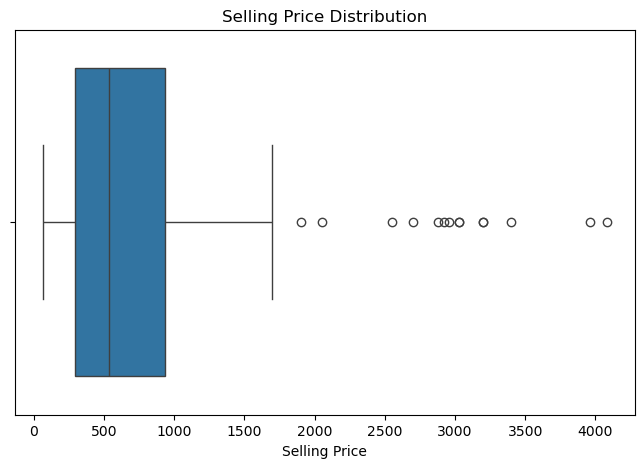

In [182]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Selling Price"])

plt.title("Selling Price Distribution")
plt.show()

### OBSERVATIONS

1. Most products are sold between ₹300 and ₹900.
2. A few products are much more expensive than the others.
3. Only a small number of products cost more than ₹1,900.


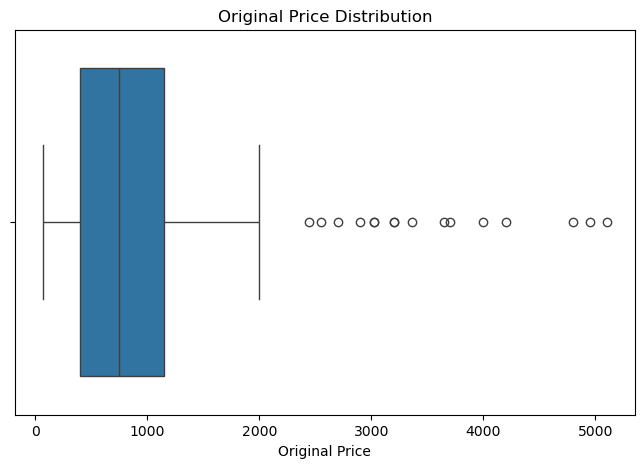

In [183]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Original Price"])

plt.title("Original Price Distribution")
plt.show()

### OBSERVATIONS

1. Most products have original prices below ₹1,200.
2. A few products are priced much higher than the rest.
3. High-priced products are rare in the dataset.


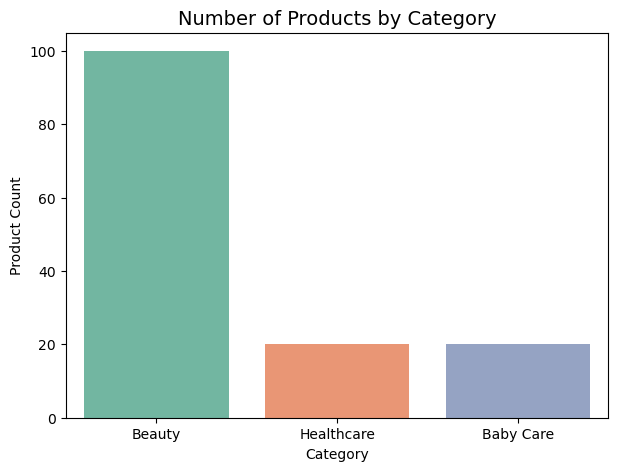

In [184]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Category", palette="Set2")

plt.title("Number of Products by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Product Count")

plt.show()

### OBSERVATIONS

1. Beauty has the highest number of products compared to the other two categories.
2. Healthcare and Baby Care have a similar number of products in the dataset.
3. The dataset is dominated by Beauty products, indicating an uneven category distribution.


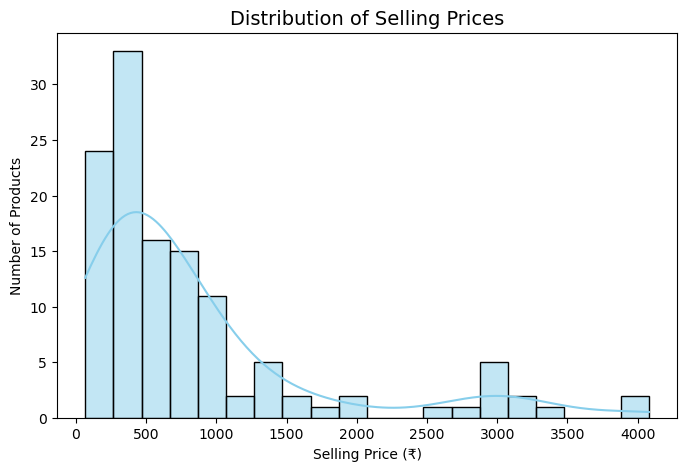

In [185]:
plt.figure(figsize=(8,5))

sns.histplot(df["Selling Price"], bins=20, kde=True, color="skyblue")

plt.title("Distribution of Selling Prices", fontsize=14)
plt.xlabel("Selling Price (₹)")
plt.ylabel("Number of Products")

plt.show()

### OBSERVATIONS

1. Most products have a selling price below ₹1,000.
2. The number of products becomes less as the selling price increases.
3. Only a few products have very high selling prices (above ₹2,000).


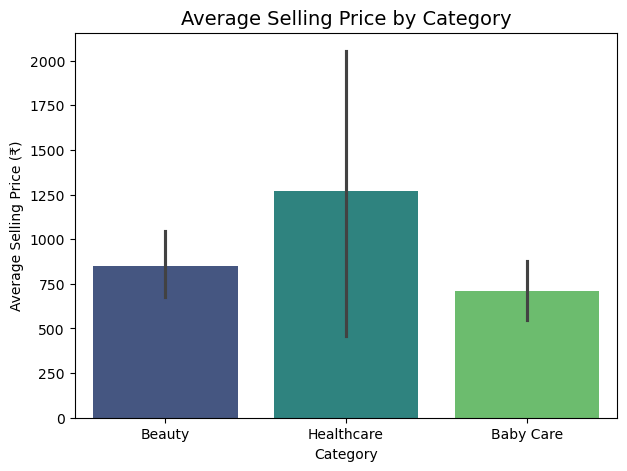

In [186]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Category",
    y="Selling Price",
    estimator="mean",
    palette="viridis"
)

plt.title("Average Selling Price by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Average Selling Price (₹)")

plt.show()

### OBSERVATIONS

1. Healthcare products have the highest average selling price among all categories.
2. Baby Care products have the lowest average selling price.
3. Beauty products have an average selling price between Healthcare and Baby Care.


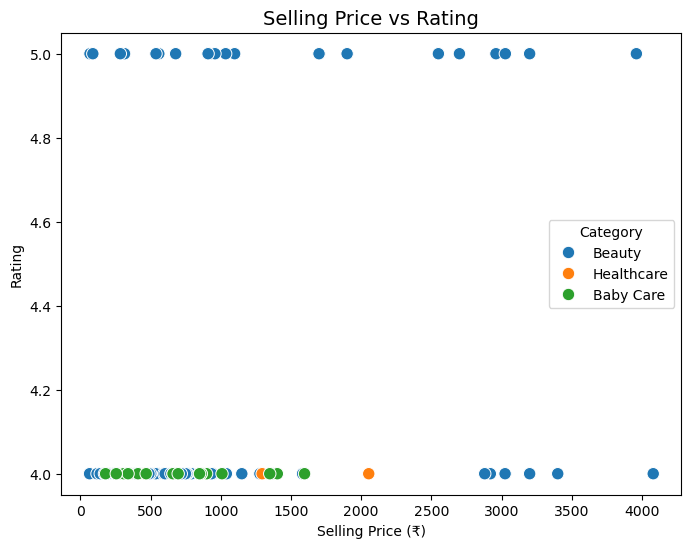

In [187]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Selling Price",
    y="Rating",
    hue="Category",
    s=80
)

plt.title("Selling Price vs Rating", fontsize=14)
plt.xlabel("Selling Price (₹)")
plt.ylabel("Rating")

plt.show()

### OBSERVATIONS

1. Most products have ratings of 4 or 5, showing generally good customer satisfaction.
2. Products with both low and high selling prices receive similar ratings.
3. There is no clear relationship between selling price and product rating.


##  CONCLUSION

This project analyzed 140 Nykaa products from the Beauty, Healthcare, and Baby Care categories using data cleaning, exploratory data analysis (EDA), and visualization.

1. Most Nykaa products are affordable, with prices below ₹1,000.
2. Beauty has the highest number of products, while Healthcare products have the highest average price.
3. Most products have good ratings (4–5 stars), showing high customer satisfaction.
4. Only a few products are premium-priced, while most are budget-friendly.
5. Product ratings do not depend on the selling price, as both low- and high-priced products receive similar ratings.
6. Overall, Nykaa offers a wide range of quality products across Beauty, Healthcare, and Baby Care categories.
